   X   Y  Cluster
0  1   2        0
1  2   3        0
2  8   9        1
3  9  10        1


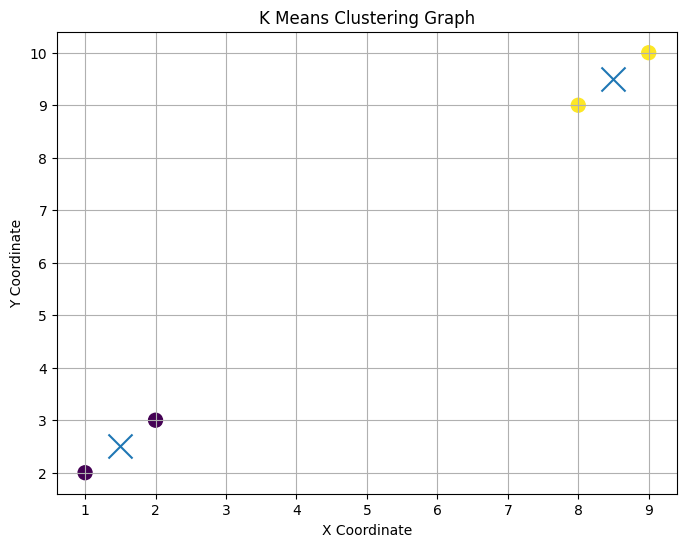

In [ ]:

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Small dataset
data = [[1, 2],
        [2, 3],
        [8, 9],
        [9, 10]]

# Convert into DataFrame
df = pd.DataFrame(data, columns=['X', 'Y'])

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=42)

# Fit the model
kmeans.fit(df)

# Predicted cluster labels
df['Cluster'] = kmeans.labels_

# Cluster centroids
centroids = kmeans.cluster_centers_

# Print dataset with cluster labels
print(df)

#Plot the cluster
plt.figure(figsize=(8,6))

#sactter plot for cluster points
plt.scatter(df['X'], df['Y'], c=df['Cluster'], s=100)

# Plot centroids
plt.scatter(centroids[:, 0], centroids[:, 1],
            marker='x',
            s=300)

# Labels and Title
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("K Means Clustering Graph")

# Show grid
plt.grid(True)

# Display plot
plt.show()

Objective of the Clustering Project

The main objective of this dataset is to perform Machine Learning Clustering Analysis on the global mental health disorder dataset to identify hidden patterns, similarities, and groupings among countries based on the prevalence of different mental health disorders.

This dataset aims to:

Analyze the distribution of mental health disorders across different countries and years.
Perform data preprocessing and feature scaling for clustering.
Apply the K-Means Clustering Algorithm to group countries with similar mental health disorder patterns.
Determine the optimal number of clusters using the Elbow Method.
Visualize clusters using scatter plots and dimensionality reduction techniques.
Interpret the characteristics of each cluster.
Draw meaningful conclusions regarding global mental health trends.

In [ ]:
# Import numerical computation library
import numpy as np

# Import pandas for dataset handling
import pandas as pd

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Import seaborn for advanced visualization
import seaborn as sns

# Ignore warning messages
import warnings
warnings.filterwarnings('ignore')


In [ ]:
from google.colab import files
df = files.upload()

Saving ML-Clustering-Dataset.csv to ML-Clustering-Dataset.csv


In [ ]:
#Read exel file
df = pd.read_csv('ML-Clustering-Dataset.csv')
# Display first  rows
df.head()

,Entity,Code,Year,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
0,Afghanistan,AFG,1990,0.223206,4.996118,4.713314,0.703023,0.127700
1,Afghanistan,AFG,1991,0.222454,4.989290,4.702100,0.702069,0.123256
2,Afghanistan,AFG,1992,0.221751,4.981346,4.683743,0.700792,0.118844
3,Afghanistan,AFG,1993,0.220987,4.976958,4.673549,0.700087,0.115089
4,Afghanistan,AFG,1994,0.220183,4.977782,4.670810,0.699898,0.111815


In [ ]:
# Check dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:\n", df.columns)

# Display data types
print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (6420, 8)

Column Names:
 Index(['Entity', 'Code', 'Year',
       'Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Depressive disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Eating disorders (share of population) - Sex: Both - Age: Age-standardized'],
      dtype='object')

Data Types:

Entity                                                                                object
Code                                                                                  object
Year                                                                                   int64
Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized    float64
Depressive disorders (share of population) - Sex: Both - Age: Age-standardized 

In [ ]:
print(df.isnull().sum())

Entity                                                                                 0
Code                                                                                 270
Year                                                                                   0
Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized      0
Depressive disorders (share of population) - Sex: Both - Age: Age-standardized         0
Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized            0
Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized            0
Eating disorders (share of population) - Sex: Both - Age: Age-standardized             0
dtype: int64


In [ ]:
df.describe()

,Year,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
count,6420.000000,6420.000000,6420.000000,6420.000000,6420.000000,6420.000000
mean,2004.500000,0.266604,3.767036,4.101840,0.636968,0.195664
std,8.656116,0.039383,0.925286,1.050543,0.233391,0.138380
min,1990.000000,0.188416,1.522333,1.879996,0.181667,0.044780
25%,1997.000000,0.242267,3.080036,3.425846,0.520872,0.096416
50%,2004.500000,0.273477,3.636772,3.939547,0.579331,0.144150
75%,2012.000000,0.286575,4.366252,4.564164,0.844406,0.251167
max,2019.000000,0.462045,7.645899,8.624634,1.506730,1.031688


In [ ]:
# Selecting numerical features only
X = df.drop(['Entity', 'Code'], axis=1)

# Display first 5 rows
X.head()

,Year,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
0,1990,0.223206,4.996118,4.713314,0.703023,0.127700
1,1991,0.222454,4.989290,4.702100,0.702069,0.123256
2,1992,0.221751,4.981346,4.683743,0.700792,0.118844
3,1993,0.220987,4.976958,4.673549,0.700087,0.115089
4,1994,0.220183,4.977782,4.670810,0.699898,0.111815


In [ ]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Scale the dataset
X_scaled = scaler.fit_transform(X)

# Display scaled data shape
print(X_scaled.shape)

(6420, 6)


In [ ]:
# Import KMeans
from sklearn.cluster import KMeans

# Create empty list for WCSS
wcss = []

# Run loop for different k values
for i in range(1, 11):

    # Create KMeans model
    kmeans = KMeans(n_clusters=i, random_state=42)

    # Fit model
    kmeans.fit(X_scaled)

    # Append inertia value
    wcss.append(kmeans.inertia_)



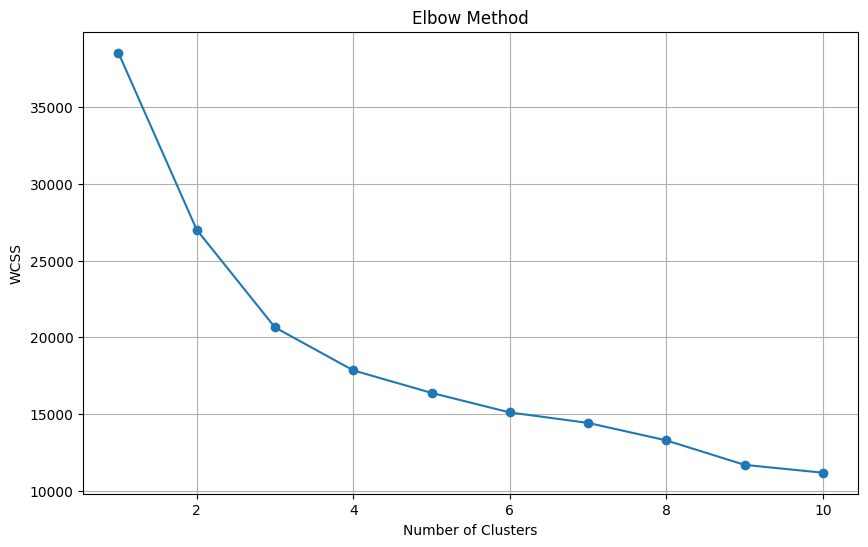

In [ ]:
# Plot elbow graph
plt.figure(figsize=(10,6))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [ ]:
# Create KMeans model
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit and predict clusters
clusters = kmeans.fit_predict(X_scaled)

# Add cluster column into dataset
df['Cluster'] = clusters

In [ ]:
# Import PCA
from sklearn.decomposition import PCA

# Create PCA object
pca = PCA(n_components=2)

# Transform scaled data
pca_components = pca.fit_transform(X_scaled)

# Create new dataframe
pca_df = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'])

# Add cluster column
pca_df['Cluster'] = clusters

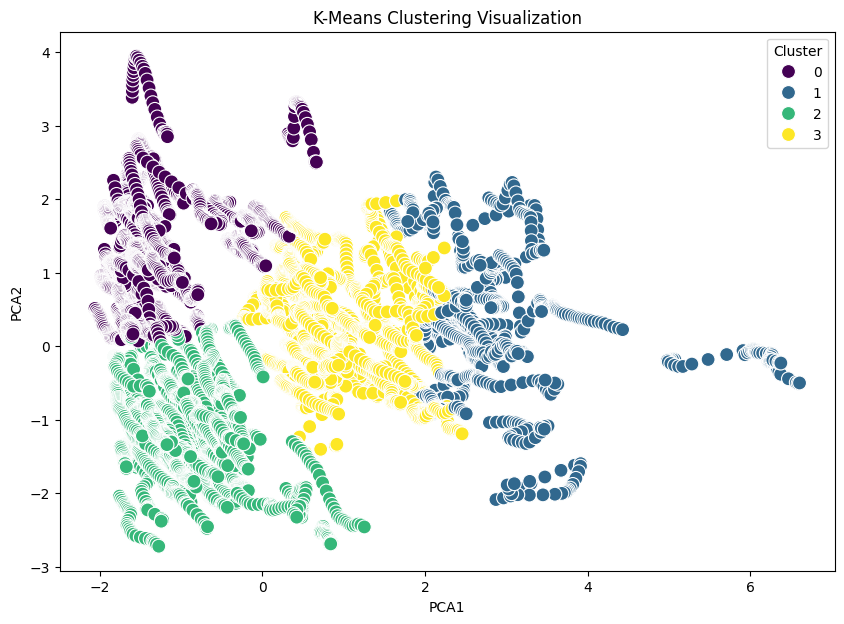

In [ ]:
# Plot clusters
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    s=100
)

plt.title('K-Means Clustering Visualization')

plt.show()

In [ ]:
# Cluster-wise average values
cluster_mean = df.groupby('Cluster').mean(numeric_only=True)

# Display analysis
print(cluster_mean)

                Year  \
Cluster                
0        2004.419158   
1        2005.706601   
2        2004.559390   
3        2003.930139   

         Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized  \
Cluster                                                                                      
0                                                 0.215325                                   
1                                                 0.306811                                   
2                                                 0.285347                                   
3                                                 0.271999                                   

         Depressive disorders (share of population) - Sex: Both - Age: Age-standardized  \
Cluster                                                                                   
0                                                 4.743433                                
1                

In [ ]:
# ----------------------------------------
# CLUSTER CENTERS
# ----------------------------------------

# Display cluster centers
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns
)

# Add cluster number
cluster_centers.index.name = 'Cluster Number'

# Display cluster centers
print("Cluster Centers:\n")
print(cluster_centers)

Cluster Centers:

                       Year  \
Cluster Number                
0               2004.419158   
1               2005.706601   
2               2004.559390   
3               2003.930139   

                Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized  \
Cluster Number                                                                                      
0                                                        0.215325                                   
1                                                        0.306811                                   
2                                                        0.285347                                   
3                                                        0.271999                                   

                Depressive disorders (share of population) - Sex: Both - Age: Age-standardized  \
Cluster Number                                                                            

In [ ]:
# ===========================================
# PCA CLUSTER VISUALIZATION
# ===========================================

# Import PCA
from sklearn.decomposition import PCA

# Create PCA object
pca = PCA(n_components=2)

# Transform scaled data into 2 dimensions
pca_components = pca.fit_transform(X_scaled)

# Create dataframe for PCA
pca_df = pd.DataFrame(
    data=pca_components,
    columns=['PCA1', 'PCA2']
)

# Add cluster labels
pca_df['Cluster'] = clusters

# Display first 5 rows
print(pca_df.head())

       PCA1      PCA2  Cluster
0 -0.401262  1.957273        0
1 -0.428366  1.948621        0
2 -0.459010  1.936674        0
3 -0.482424  1.930610        0
4 -0.499702  1.931251        0


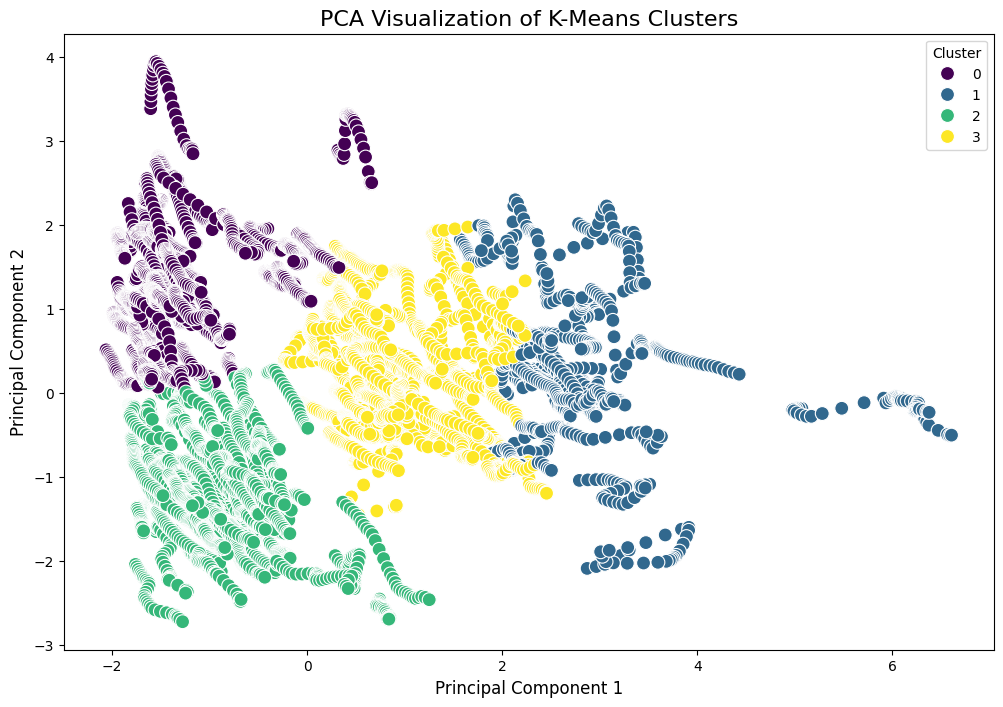

In [ ]:
# ===========================================
# PCA SCATTER PLOT
# ===========================================

# Set figure size
plt.figure(figsize=(12,8))

# Create scatter plot
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    s=100
)

# Plot title
plt.title('PCA Visualization of K-Means Clusters', fontsize=16)

# X-axis label
plt.xlabel('Principal Component 1', fontsize=12)

# Y-axis label
plt.ylabel('Principal Component 2', fontsize=12)

# Show legend
plt.legend(title='Cluster')

# Show graph
plt.show()

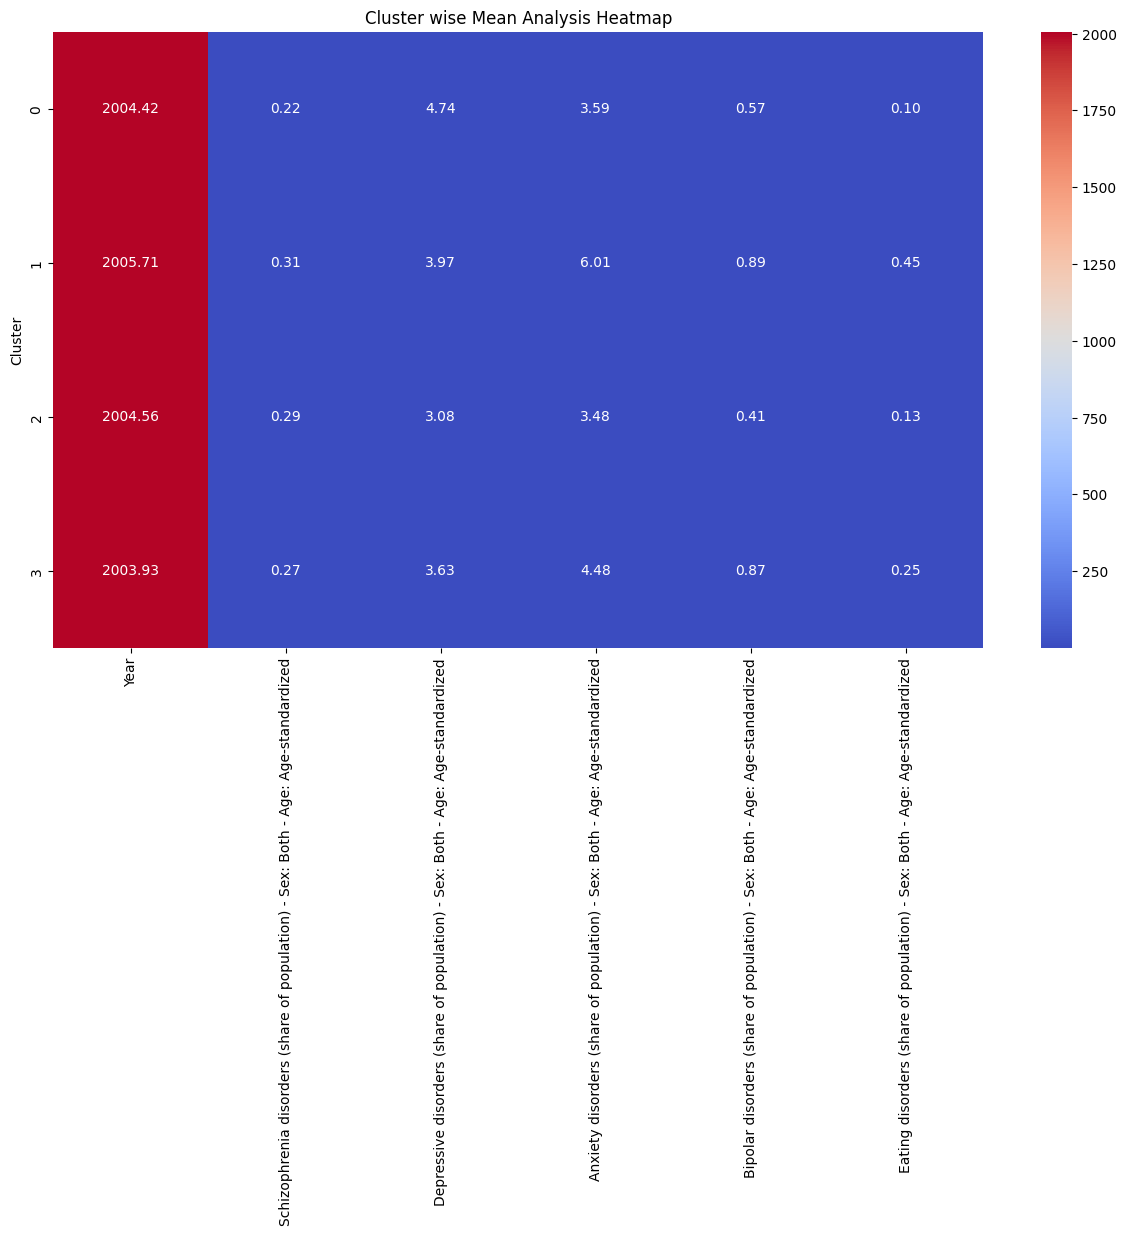

In [ ]:
# ===========================================
# HEATMAP OF CLUSTER MEANS
# ===========================================

# Set figure size
plt.figure(figsize=(15,8))

# Create heatmap
sns.heatmap(
    cluster_mean,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

# Title
plt.title('Cluster wise Mean Analysis Heatmap')

# Show graph
plt.show()